In [1]:
import os
import sys
from pathlib import Path
import math
import random
from matplotlib import pyplot as plt

from starplot.models import Constellation
from shapely.geometry import Polygon, MultiPolygon
from starplot import Observer

current_dir = Path.cwd()
parent_dir = current_dir.parent

sys.path.append(str(parent_dir))

from src.choose_observer import *
from src.utils import *
from src.plot import *

In [2]:
lat = math.radians(40.195203)
sid = math.radians(1.946264*15)
ra = math.radians(4.797572)
dec = math.radians(-9.854662)

alt = math.radians(90 - 54.905788)
azi = math.radians(209.82620)

print(f'lat: {lat}\nsid: {sid}\nazi: {azi}\nalt: {alt}\nra: {ra}\ndec: {dec}')

lat: 0.7015386358575023
sid: 0.5095307236955238
azi: 3.662158046948126
alt: 0.6125095477929042
ra: 0.08373342750148939
dec: -0.17199629857116944


In [3]:
ra_e, dec_e = azi_alt_to_ra_dec(sid, lat, azi, alt)

print(math.isclose(ra_e, ra, rel_tol=0.001) and math.isclose(dec_e, dec, rel_tol=0.001))

True


In [4]:
azi_e, alt_e = ra_dec_to_azi_alt(sid, lat, ra, dec)

print(math.isclose(azi_e, azi, rel_tol=0.001) and math.isclose(alt_e, alt, rel_tol=0.001))

True


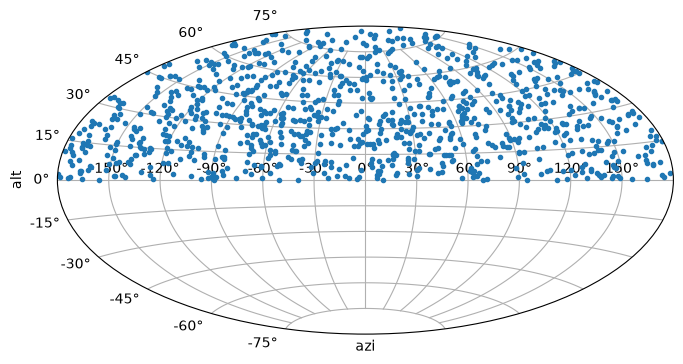

In [5]:
azis = []
alts = []
rng = random.Random(1)
for _ in range(1000):
    az, al = generate_point(rng)
    azis.append(az - math.pi)
    alts.append(al)

plt.figure(figsize = (8,4))
plt.subplot(111, projection="aitoff")
plt.grid(True)
plt.plot(azis, alts, '.')
plt.xlabel('azi')
plt.ylabel('alt')
plt.show()

In [ ]:
ds = []
for i in range(len(constellation_set)):
    for j in range(i + 1, len(constellation_set)):
        ra1, dec1 = constellation_centroid(constellation_set[i])
        ra2, dec2 = constellation_centroid(constellation_set[j])
        ds.append(haversine(ra1, dec1, ra2, dec2))

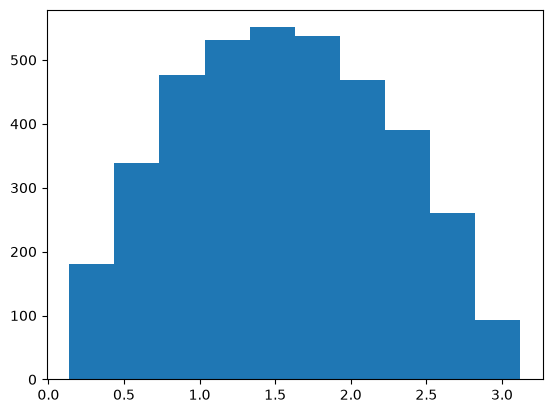

In [ ]:
plt.hist(ds)
plt.show()

In [2]:
observer = choose_observer('oct', 'umi', random.Random())[0]
metrics = constellation_counter(values={"cyg": 1, "ori": 2, "and": 3})

make_dual_plot(observer, metrics)

In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo

from starplot import ZenithPlot, Observer, _
from starplot.styles import PlotStyle, extensions

from starplot import CollisionHandler

tz = ZoneInfo("America/Los_Angeles")
dt = datetime(2023, 7, 13, 22, 0, tzinfo=tz)  # July 13, 2023 at 10pm PT

observer = Observer(
    dt=dt,
    lat=33.363484,
    lon=-116.836394,
)

p = ZenithPlot(
    observer=observer,
    style=PlotStyle().extend(
        extensions.BLUE_MEDIUM,
    ),
    resolution=1024,
    autoscale=True,
)
p.horizon()
p.constellations()
p.stars(where=[_.magnitude < 4.6], where_labels=[_.magnitude < -10])
p.constellation_borders()
p.constellation_labels(
    collision_handler=CollisionHandler(
        attempts=4,
        plot_on_fail=True,
        allow_label_collisions=True, 
        allow_constellation_line_collisions=True
    )
)

for text in p.ax.texts:
    text.set_clip_path(p.ax.patch)
    text.set_clip_on(True)

colors = choose_colors(2)

for abbr in constellation_set:
    if abbr == 'ser':
        highlight_constellation(p, iau_id='ser1', fill_color=colors[0], alpha=0.25)
        highlight_constellation(p, iau_id='ser2', fill_color=colors[0], alpha=0.25)
    else:
        highlight_constellation(p, iau_id=abbr, fill_color=colors[0], alpha=0.25)

p.export("star_chart_basic.png", transparent=True, padding=0.1)